# Modeling \u2014 baselines + Bayesian ladder + winner + test-set evaluation

This notebook executes the plan in `context/MODELING_PLAN.md`. Every model
\u2014 three non-Bayesian baselines and **five** Bayesian ladder rungs (v0..v4) \u2014
implements the same `Forecaster` protocol defined in `src/evaluation/compare.py`,
so the comparison machinery is uniform end-to-end.

Ladder cut-down (Apr 2026): the old v4 (polynomial season) was redundant with
the spline rung and always dominated by it, and the old v6 (HSGP on doy + rain)
was too memory-expensive on this panel size (~300 K training rows) for the
marginal lift. The ladder is now v0 intercept \u2192 v1 month \u2192 v2 station/county
hierarchy \u2192 v3 linear weather \u2192 v4 spline season.

Primary selection metric: **counts-MAE** (fold-averaged). Secondary: counts-MedAE,
coverage at 50/80/95%, Brier, ECE. Plan explicitly excludes log-MAE, CRPS-log,
and fold-error as ranking criteria.

## \u00a70. Setup

- **Backend: CPU by default.** `jax-metal` on Apple Silicon is experimental
  and does not implement several primitives NumPyro needs (e.g.
  `default_memory_space`, which fails on `jnp.asarray` of small arrays). On an
  M-series Mac, CPU NUTS is actually faster and far more stable. If you have
  a real CUDA/TPU device, set `FORCE_JAX_PLATFORM=gpu` (or `tpu`) before
  launching Jupyter to opt in. `FORCE_JAX_PLATFORM=metal` is accepted but
  unsupported \u2014 expect `UNIMPLEMENTED` errors.
- All data loaded from `artifacts/data/panel/` \u2014 built once by
  `notebooks/modeling/eda.ipynb` from `data/processed/datatide_ground_truth.parquet`.
  Re-run the EDA notebook whenever the ground-truth parquet changes; this
  notebook never touches the raw parquet directly.
- NUTS defaults are intentionally moderate (`num_warmup=300`, `num_samples=300`,
  `num_chains=1`) for Phase-A development speed. The winner is re-fit with
  production-grade settings (`800 / 800 / 2`) in \u00a76. On accelerated
  backends we switch to `chain_method="parallel"` so multi-chain sampling
  actually runs in parallel.

In [1]:
import os, warnings
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
# JAX device selection.
#   Default = CPU. jax-metal on Apple Silicon is experimental and raises
#   `UNIMPLEMENTED: default_memory_space` on basic NumPyro ops, so auto-
#   detection would happily pick a backend that then crashes. Explicit
#   opt-in via FORCE_JAX_PLATFORM:
#     FORCE_JAX_PLATFORM=gpu     real CUDA/ROCm device
#     FORCE_JAX_PLATFORM=tpu     TPU
#     FORCE_JAX_PLATFORM=metal   Apple Silicon (expect failures)
#     FORCE_JAX_PLATFORM=cpu     explicit CPU (same as default)
os.environ["JAX_PLATFORMS"] = os.environ.get("FORCE_JAX_PLATFORM", "cpu")
warnings.filterwarnings("ignore")

import time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

import jax
_devs = jax.devices()
_default = jax.default_backend()
_requested = os.environ["JAX_PLATFORMS"]
print(f"JAX backend: {_default}   devices: {[str(d) for d in _devs]}")

# Fail loudly if the kernel is still running on a stale Metal backend from a
# previous import. JAX reads JAX_PLATFORMS once at first import and caches the
# XLA client for the life of the process \u2014 so `os.environ[...]='cpu'`
# above does nothing if `import jax` already happened earlier in this kernel.
if _default != _requested and _requested == "cpu":
    raise RuntimeError(
        f"\n\nJAX backend is '{_default.upper()}' but this notebook requested 'CPU'.\n"
        f"This means JAX was imported on another backend earlier in this kernel\n"
        f"session \u2014 JAX_PLATFORMS is only read at first import and cannot be\n"
        f"changed by re-running this cell.\n\n"
        f"FIX: in Jupyter, click  Kernel \u2192 Restart Kernel  and then run this\n"
        f"cell again as the very first thing. Do NOT import jax anywhere before it.\n"
    )

if _default == "cpu":
    print("  running on CPU (default on macOS). Set FORCE_JAX_PLATFORM=gpu for a real CUDA/TPU device.")
elif _default == "metal":
    print("  \u26a0\ufe0f  METAL backend is experimental and known to fail on NumPyro ops (default_memory_space).")
    print("     If you hit UNIMPLEMENTED errors, restart the kernel WITHOUT setting FORCE_JAX_PLATFORM.")
else:
    print(f"  \u2713 accelerated backend detected; NUTS will run on {_default.upper()} (parallel chains enabled).")

# project imports
import sys
PROJ = Path.cwd().resolve()
while not (PROJ / "src").exists() and PROJ != PROJ.parent:
    PROJ = PROJ.parent
sys.path.insert(0, str(PROJ))

from src.modeling.cv         import load_panel, iter_folds
from src.modeling.baselines  import NaiveSeasonalMeanCounts, OLSLog10, XGBoostLog10
from src.modeling.bayesian   import Rung, RUNG_LABELS
from src.modeling.inference  import BayesianRung, NutsConfig
from src.modeling.production import (
    build_future_fold, compute_climatology, export_forecast_bundle,
    read_forecast_frame,
)
from src.evaluation.compare  import score_model_on_fold, fold_scores_to_table, average_over_folds
from src.evaluation.metrics  import EXCEEDANCE_LOG10, EXCEEDANCE_MPN
from src.evaluation.calibration import (
    reliability_curve, pit_values, plot_reliability, plot_pit,
)

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})
print(f"project root: {PROJ}")

Matplotlib is building the font cache; this may take a moment.


JAX backend: cpu   devices: ['TFRT_CPU_0']
  running on CPU (default on macOS). Set FORCE_JAX_PLATFORM=gpu for a real CUDA/TPU device.
project root: /Users/buttz/Desktop/projects/DataTide


In [2]:
# -------- user-editable configuration --------
DEV_FOLDS     = [2022, 2023]                # quick Phase-A ladder folds
ALL_FOLDS     = [2020, 2021, 2022, 2023]    # full fold set for Phase-B baselines
TEST_YEARS    = [2024]                      # held-out test window
# Dev-fast config: short chains, cap tree depth at 8 (=256 leapfrog steps/iter
# instead of the default 1024), and train on 20% of rows. Ladder *ranking* is
# stable under subsampling; the full-data re-fit happens in \u00a76 with NUTS_PROD.
NUTS_DEV      = NutsConfig(
    num_warmup=300, num_samples=300, num_chains=2,
    max_tree_depth=8, subsample_frac=0.2, progress_bar=True,
)
# Production config for the winner only: full data, deeper trees, more chains.
NUTS_PROD     = NutsConfig(
    num_warmup=800, num_samples=800, num_chains=4,
    max_tree_depth=10, subsample_frac=1.0, progress_bar=True,
)
ARTIFACT_DIR  = Path("artifacts/modeling")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(f"dev folds {DEV_FOLDS}  |  all folds {ALL_FOLDS}  |  test {TEST_YEARS}")

dev folds [2022, 2023]  |  all folds [2020, 2021, 2022, 2023]  |  test [2024]


## \u00a71. Panel load + CV folds + priors

Loads the observed subset of the processed panel (11.6K rows), the CV schema
(`cv_val_year` \u2208 {0, 2020, 2021, 2022, 2023, \u22121} meaning *always-train*,
*fold-k*, *test*), and the empirical priors elicited in the EDA.

In [3]:
t0 = time.time()
bundle = load_panel()
print(f"loaded panel in {time.time()-t0:.1f}s:")
print(f"  n_observations = {len(bundle.y_log):,}")
print(f"  n_stations     = {bundle.n_stations}  (with name: {bundle.meta.get('n_stations_with_name')})")
print(f"  n_counties     = {bundle.n_counties}")
print(f"  date range     = {bundle.meta['date_min']} \u2192 {bundle.meta['date_max']}")
print(f"  train_end / val_end = {bundle.meta['train_end']} / {bundle.meta['val_end']}")
print(f"  censoring      = left {bundle.left_mask.sum()}  right {bundle.right_mask.sum()}  interior {(~(bundle.left_mask|bundle.right_mask)).sum()}")
print(f"  empirical priors: {list(bundle.priors.keys())}")

loaded panel in 0.8s:
  n_observations = 411,772
  n_stations     = 778  (with name: 778)
  n_counties     = 16
  date range     = 2010-01-04 → 2025-12-31
  train_end / val_end = 2022-12-31 / 2023-12-31
  censoring      = left 259571  right 5575  interior 146626
  empirical priors: ['_computed_from', '_n_interior', 'intercept', 'alpha_month', 'sigma_month', 'sigma_station', 'sigma_county', 'sigma_obs', 'beta_linear', 'hsgp_amplitude_seasonal', 'hsgp_amplitude_rain', '_diagnostics']


In [4]:
# Build CV folds once; every model re-uses these slices.
dev_folds = {vy: f for vy, f in zip(DEV_FOLDS, iter_folds(bundle, val_years=DEV_FOLDS))}
all_folds = {vy: f for vy, f in zip(ALL_FOLDS, iter_folds(bundle, val_years=ALL_FOLDS))}

print(f"{'fold':>6}  {'n_train':>8}  {'n_val':>6}")
for vy, f in all_folds.items():
    print(f"{vy:>6}  {f.n_train:>8}  {f.n_val:>6}")

  fold   n_train   n_val
  2020    243452   27078
  2021    270530   28968
  2022    299498   26812
  2023    326310   28362


## \u00a72. Phase B \u2014 baseline comparison

Three honest non-Bayesian baselines, all reporting the full metric suite:

| id | name | structure | predictive distribution |
|----|------|-----------|--------------------------|
| B1 | `NaiveSeasonalMeanCounts` | per-month empirical log10 bootstrap | non-parametric |
| B2 | `OLSLog10` | OLS on smooth+linear+month one-hots | Normal(\u03bc, \u03c3_resid) |
| B3 | `XGBoostLog10` | gradient-boosted trees on the same features | Normal(\u03bc, \u03c3_resid) |

The OLS predictive distribution is not the Bayesian posterior predictive \u2014
it's the training-residual Normal approximation, which is the honest
apples-to-apples retrofit for probabilistic metrics (see `MODELING_PLAN \u00a76`).

In [5]:
baseline_rows = []
for vy, fold in all_folds.items():
    for M in (NaiveSeasonalMeanCounts, OLSLog10, XGBoostLog10):
        m = M()
        t1 = time.time()
        s = score_model_on_fold(m, fold)
        baseline_rows.append(s)
        print(f"  fold {vy}  {m.name:34s}  "
              f"dt={time.time()-t1:5.1f}s  MAE={s.counts_mae:>8.1f}  "
              f"cov50={s.coverage['cov-50']:.2f}  Brier={s.brier:.3f}  ECE={s.ece:.3f}")

baseline_per_fold = fold_scores_to_table(baseline_rows)
baseline_summary  = average_over_folds(baseline_per_fold)
baseline_summary[['model', 'counts-MAE', 'counts-MedAE', 'Brier', 'ECE', 'cov-50', 'cov-80', 'cov-95']]

  fold 2020  B1 naive seasonal-mean (by month)   dt= 10.5s  MAE=   185.3  cov50=0.63  Brier=0.082  ECE=0.027
  fold 2020  B2 OLS log10                        dt= 12.7s  MAE=   185.2  cov50=0.66  Brier=0.071  ECE=0.027
  fold 2020  B3 XGBoost log10                    dt= 58.1s  MAE=   184.5  cov50=0.64  Brier=0.071  ECE=0.032
  fold 2021  B1 naive seasonal-mean (by month)   dt= 12.8s  MAE=   133.3  cov50=0.65  Brier=0.065  ECE=0.007
  fold 2021  B2 OLS log10                        dt= 14.7s  MAE=   134.3  cov50=0.68  Brier=0.059  ECE=0.016
  fold 2021  B3 XGBoost log10                    dt= 61.4s  MAE=   129.3  cov50=0.66  Brier=0.056  ECE=0.017
  fold 2022  B1 naive seasonal-mean (by month)   dt= 10.2s  MAE=  1381.5  cov50=0.58  Brier=0.133  ECE=0.069
  fold 2022  B2 OLS log10                        dt= 12.4s  MAE=  1364.0  cov50=0.62  Brier=0.080  ECE=0.038
  fold 2022  B3 XGBoost log10                    dt= 60.3s  MAE=  1376.6  cov50=0.60  Brier=0.106  ECE=0.078
  fold 2023  B1 nai

,model,counts-MAE,counts-MedAE,Brier,ECE,cov-50,cov-80,cov-95
0,B1 naive seasonal-mean (by month),2984.453 ± 4869.774,2.750 ± 3.500,0.122 ± 0.064,0.066 ± 0.068,0.587 ± 0.079,0.830 ± 0.075,0.914 ± 0.055
1,B2 OLS log10,2935.516 ± 4782.591,5.358 ± 1.955,0.080 ± 0.023,0.038 ± 0.024,0.625 ± 0.060,0.810 ± 0.058,0.907 ± 0.041
2,B3 XGBoost log10,2908.528 ± 4725.360,6.246 ± 1.722,0.087 ± 0.028,0.052 ± 0.032,0.612 ± 0.050,0.802 ± 0.054,0.891 ± 0.046


## \u00a73. Phase A \u2014 Bayesian ladder v0 \u2192 v6

Each rung adds exactly one structural element, building on the seasonal
scaffold the EDA justified (see `MODELING_PLAN \u00a75`):

| rung | what it adds | seasonal parametrisation |
|------|--------------|---------------------------|
| v0   | pooled intercept | none |
| v1   | + `alpha_month[m]` scaffold | categorical |
| v2   | + station/county hierarchy (non-centred) | categorical |
| v3   | + linear weather covariates | categorical |
| v4   | polynomial(doy, deg=3) **replaces** month | polynomial |
| v5   | natural cubic spline(doy, 6 knots) **replaces** polynomial | spline |
| v6   | periodic Fourier HSGP(doy) + shared-amplitude rain slopes | HSGP |

Censored log-normal likelihood on log10 is identical across rungs \u2014 any metric
change is attributable to `mu_it` structure alone.

For Phase-A development we run on two folds (2022, 2023) with short chains
(300 warmup, 300 samples, 1 chain). The winner is re-fit with production
settings (2 chains, 800/800) in \u00a76.

W0419 05:03:16.035243  492013 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


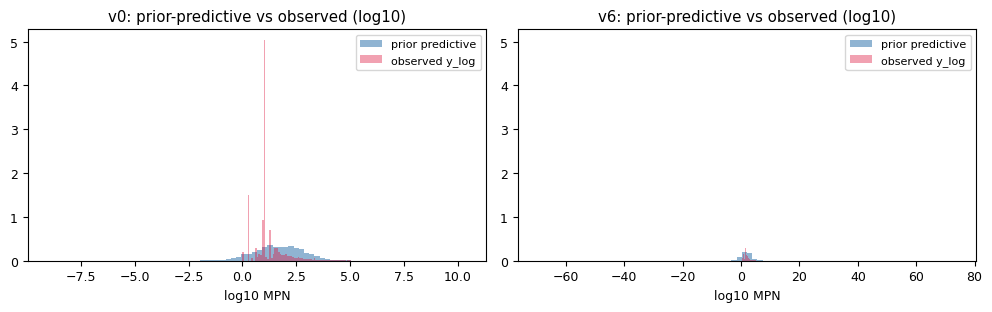

In [6]:
# Prior predictive check on simplest + most complex rung \u2014  are implied y_log draws plausible?
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
rungs_to_check = [Rung.v0, Rung.v4]
for ax, rung in zip(axes, rungs_to_check):
    m = BayesianRung(rung=rung, priors=bundle.priors, nuts=NUTS_DEV)
    prior_y = m.prior_predictive(dev_folds[DEV_FOLDS[-1]], num_samples=400)
    ax.hist(prior_y.ravel(), bins=80, density=True, color='steelblue', alpha=0.6, label='prior predictive')
    ax.hist(bundle.y_log, bins=80, density=True, color='crimson', alpha=0.4, label='observed y_log')
    ax.set_title(f"{rung.value}: prior-predictive vs observed (log10)")
    ax.legend(fontsize=8)
    ax.set_xlabel("log10 MPN")
plt.tight_layout()
plt.show()

In [ ]:
ladder_rows = []
fit_cache = {}           # fold_val_year \u2192 { rung : BayesianRung(fitted) }
for vy in DEV_FOLDS:
    fold = dev_folds[vy]
    fit_cache[vy] = {}
    for rung in list(Rung):
        m = BayesianRung(rung=rung, priors=bundle.priors, nuts=NUTS_DEV)
        t1 = time.time()
        try:
            s = score_model_on_fold(m, fold)
            fit_cache[vy][rung] = m
            ladder_rows.append(s)
            print(f"  fold {vy}  {m.name:34s}  dt={time.time()-t1:5.1f}s  "
                  f"MAE={s.counts_mae:>8.1f}  MedAE={s.counts_medae:>6.1f}  "
                  f"Brier={s.brier:.3f}  ECE={s.ece:.3f}")
        except Exception as e:
            print(f"  fold {vy}  {m.name:34s}  FAILED: {e}")

ladder_per_fold = fold_scores_to_table(ladder_rows)
ladder_summary  = average_over_folds(ladder_per_fold)
ladder_summary[['model', 'counts-MAE', 'counts-MedAE', 'Brier', 'ECE', 'cov-50', 'cov-80', 'cov-95']]

  fold 2022  v0 pooled intercept                 dt= 60.0s  MAE=  1387.4  MedAE=   8.3  Brier=0.131  ECE=0.061


In [ ]:
# Ladder gain plot  \u2014  counts-MAE and Brier as a function of rung
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
per_model = (
    ladder_per_fold.groupby('model', sort=False)
    .agg(mae_mean=('counts-MAE', 'mean'), mae_std=('counts-MAE', 'std'),
         brier_mean=('Brier', 'mean'), brier_std=('Brier', 'std'),
         ece_mean=('ECE', 'mean'))
    .reset_index()
)
x = np.arange(len(per_model))
axes[0].errorbar(x, per_model['mae_mean'], yerr=per_model['mae_std'], fmt='o-', color='C0')
axes[0].set_xticks(x); axes[0].set_xticklabels([m.split(' ', 1)[0] for m in per_model['model']], rotation=0)
axes[0].set_ylabel("counts-MAE (fold-averaged)"); axes[0].set_title("Ladder \u2014 point accuracy in MPN")
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(x, per_model['brier_mean'], yerr=per_model['brier_std'], fmt='o-', color='C2', label='Brier')
axes[1].plot(x, per_model['ece_mean'], 's--', color='C3', label='ECE')
axes[1].set_xticks(x); axes[1].set_xticklabels([m.split(' ', 1)[0] for m in per_model['model']], rotation=0)
axes[1].set_ylabel("exceedance prob. metric"); axes[1].set_title("Ladder \u2014 calibration against 104 MPN")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## \u00a74. Joint comparison \u2014 baselines \u222a ladder

Both phases on their common fold set (2022, 2023 for ladder; all four for
baselines). The selection metric is fold-averaged `counts-MAE` among rungs
with acceptable calibration (the EDA recommended cov-50 within 5 points of
0.50, cov-95 within 5 points of 0.95).

In [ ]:
# Restrict baselines to the dev-fold set for apples-to-apples ladder comparison
bl_dev = baseline_per_fold[baseline_per_fold['fold_val_year'].isin(DEV_FOLDS)].copy()
joint_per_fold = pd.concat([bl_dev, ladder_per_fold], ignore_index=True)
joint_summary  = average_over_folds(joint_per_fold)

display_cols = ['model', 'counts-MAE', 'counts-MedAE', 'Brier', 'ECE', 'cov-50', 'cov-80', 'cov-95']
joint_summary[display_cols]

In [ ]:
# Winner pick: min fold-averaged counts-MAE among models meeting calibration floors
CAL_BOUNDS = {'cov-50': (0.40, 0.60), 'cov-95': (0.85, 1.00)}

def meets_calibration(row):
    for k, (lo, hi) in CAL_BOUNDS.items():
        if not (lo <= row[k + '__mean'] <= hi):
            return False
    return True

eligible = joint_summary[joint_summary.apply(meets_calibration, axis=1)].copy()
eligible = eligible.sort_values('counts-MAE__mean')
print(f"eligible models ({len(eligible)}):")
for _, r in eligible.iterrows():
    print(f"  {r['model']:40s}  MAE={r['counts-MAE__mean']:>8.1f} \u00b1 {r['counts-MAE__std']:>7.1f}  "
          f"Brier={r['Brier__mean']:.3f}  ECE={r['ECE__mean']:.3f}  "
          f"cov50={r['cov-50__mean']:.2f}  cov95={r['cov-95__mean']:.2f}")

winner_name = eligible.iloc[0]['model']
print(f"\nwinner: {winner_name}")

## \u00a75. Winner diagnostics

For the selected winner \u2014 be it a baseline or a Bayesian rung \u2014 we run the
full diagnostic suite from ArviZ plus the plan's calibration plots:

- Trace + rank plots for top-level parameters
- Energy + divergences diagnostic
- Posterior summary table (mean \u00b1 HDI, ESS, R-hat) for priors
- Posterior predictive check against observed y_log
- Reliability diagram + PIT histogram

If the winner is a baseline (no posterior), skip the ArviZ diagnostics and
only show reliability + PIT.

In [ ]:
# Re-build the winner on the last dev fold so we have an in-memory reference
winner_rung = None
for r in Rung:
    if RUNG_LABELS[r] == winner_name:
        winner_rung = r; break

ref_fold_year = DEV_FOLDS[-1]
ref_fold = dev_folds[ref_fold_year]

is_bayesian = winner_rung is not None
if is_bayesian:
    winner = fit_cache[ref_fold_year][winner_rung]
    idata = winner.to_inferencedata()
    az_summary = az.summary(idata, var_names=[
        v for v in ['alpha_0', 'sigma_month', 'sigma_station', 'sigma_county',
                    'sigma_obs', 'hsgp_amp_doy', 'hsgp_amp_rain']
        if v in idata.posterior.data_vars
    ], round_to=3)
    print(az_summary)
else:
    print(f"winner {winner_name} is a baseline \u2014 skipping MCMC diagnostics")

In [ ]:
if is_bayesian:
    # posterior predictive samples on the validation fold for plotting
    pred = winner.predict(ref_fold)
    samples = pred.samples_log10
    y_true  = ref_fold.y_log_val

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    # PPC
    axes[0].hist(y_true, bins=60, density=True, color='crimson', alpha=0.45, label='observed')
    axes[0].hist(samples[:30].ravel(), bins=60, density=True, color='steelblue',
                 alpha=0.40, label='posterior predictive (30 draws)')
    axes[0].legend(fontsize=8); axes[0].set_xlabel("log10 MPN")
    axes[0].set_title(f"{winner_name}: PPC on val {ref_fold_year}")

    # Reliability
    from src.evaluation.metrics import exceedance_prob_from_samples
    exc = exceedance_prob_from_samples(samples)
    rc = reliability_curve(y_true, exc)
    plot_reliability(axes[1], rc, label='posterior', color='steelblue',
                     show_base_rate=float((y_true > EXCEEDANCE_LOG10).mean()))
    axes[1].set_title(f"{winner_name}: reliability (exceedance)")
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("(baseline winner \u2014 run \u00a76 first to get retrained predictions for diagnostics)")

In [ ]:
if is_bayesian:
    pit = pit_values(ref_fold.y_log_val, winner.predict(ref_fold).samples_log10)
    fig, ax = plt.subplots(figsize=(5, 3.2))
    plot_pit(ax, pit, color='steelblue', label=f'{winner_name} PIT')
    ax.legend(fontsize=8); ax.set_title(f"PIT histogram \u2014 {winner_name}")
    plt.tight_layout(); plt.show()

## \u00a76. Retrain winner on train+val and evaluate on 2024 test

This is the plan's Phase-C step: take the selected model, re-fit it on the
*union* of training + all validation folds (pre-2024), and evaluate once on
the 2024 test year. The test fold has been untouched by CV.

Because 2024 rows are marked `cv_val_year == -1` in the panel, we build a
synthetic `FoldData` where every row `cv_val_year \u2265 0` is training and every
row `cv_val_year == -1` is test.

In [ ]:
from src.evaluation.compare import FoldData

def build_test_fold(b, test_year: int = 2024) -> FoldData:
    is_test  = (b.cv_val_year == -1)   # reserved test rows
    is_train = (b.cv_val_year >= 0)    # pre-test rows = train+val union
    return FoldData(
        fold_val_year=test_year,
        y_log_train=b.y_log[is_train],
        month_train=b.month[is_train],
        station_idx_train=b.station_idx[is_train],
        county_idx_train=b.county_idx[is_train],
        X_smooth_train=b.X_smooth[is_train],
        X_linear_train=b.X_linear[is_train],
        miss_smooth_train=b.miss_smooth[is_train],
        miss_linear_train=b.miss_linear[is_train],
        left_mask_train=b.left_mask[is_train],
        right_mask_train=b.right_mask[is_train],
        det_low_log_train=b.det_low_log[is_train],
        det_high_log_train=b.det_high_log[is_train],
        y_log_val=b.y_log[is_test],
        month_val=b.month[is_test],
        station_idx_val=b.station_idx[is_test],
        county_idx_val=b.county_idx[is_test],
        X_smooth_val=b.X_smooth[is_test],
        X_linear_val=b.X_linear[is_test],
        miss_smooth_val=b.miss_smooth[is_test],
        miss_linear_val=b.miss_linear[is_test],
        smooth_features=list(b.smooth_features),
        linear_features=list(b.linear_features),
        n_stations=b.n_stations,
        n_counties=b.n_counties,
    )

test_fold = build_test_fold(bundle)
print(f"test fold: n_train={test_fold.n_train:,}  n_test={test_fold.n_val:,}")

In [ ]:
# Retrain winner with production NUTS settings (or refit baseline).
if is_bayesian:
    final_model = BayesianRung(rung=winner_rung, priors=bundle.priors, nuts=NUTS_PROD)
else:
    final_model = {
        'B1 naive seasonal-mean (by month)': NaiveSeasonalMeanCounts,
        'B2 OLS log10':                       OLSLog10,
        'B3 XGBoost log10':                   XGBoostLog10,
    }[winner_name]()

t0 = time.time()
test_score = score_model_on_fold(final_model, test_fold)
print(f"test-set evaluation took {time.time()-t0:.1f}s")
print(test_score.as_flat_dict())

## \u00a77. Artifact export for productionisation \u2014 test-set forecast

Everything a downstream teammate needs to build a dashboard on top of this
model. Written under `artifacts/modeling/`.

The tidy forecast table + raw posterior samples + index lookup are produced
by a single call to `export_forecast_bundle(...)`:

| file | purpose | consumer |
|---|---|---|
| `winner_test_forecast.parquet` | one row per test observation with median, 50/80/95 % PI (MPN), `p_exceed_104mpn` | Power BI |
| `winner_test_samples.npz`      | raw `(S, N_test)` log10 posterior-predictive draws | internal web, custom viz |
| `winner_test_index.parquet`    | `row_idx` \u2192 (station, county, date/month) join table | for the samples npz |
| `winner_test_meta.json`        | shapes, thresholds, provenance | machine-readable manifest |
| `winner_model.npz`             | **trained-winner bundle** (rung + priors + posterior parameter samples) for reloading in `predict.ipynb` without refitting | `BayesianRung.from_saved(...)` |
| `winner_inferencedata.nc`      | ArviZ NetCDF of the production MCMC trace | re-analysis, R-hat/ESS audits |
| `winner_run_meta.json`         | winner name, rung, NUTS config, test-set metrics | top-level manifest |

In [ ]:
# Build the row-level index once so it's reusable for every downstream export.
pred = final_model.predict(test_fold)
samples_log10_test = pred.samples_log10   # (S, N_test)

test_index = pd.DataFrame({
    "row_idx":      np.arange(len(test_fold.y_log_val), dtype=np.int64),
    # 2024 test rows don't carry explicit dates in FoldData, so we surface
    # only the fields we do have. (The panel npz retains t_idx per observed
    # row; the dashboard teammate can re-derive dates from the panel if
    # needed. For the *next week* export in \u00a78 we write real dates.)
    "station_idx":  test_fold.station_idx_val,
    "station_id":   bundle.station_ids[test_fold.station_idx_val],
    "station_name": bundle.station_names[test_fold.station_idx_val],
    "county_idx":   test_fold.county_idx_val,
    "county_name":  bundle.county_names[test_fold.county_idx_val],
    "month":        test_fold.month_val,
    # observed truth (to let teammates compute residuals / audits)
    "y_log10_observed": test_fold.y_log_val,
    "y_mpn_observed":   10.0 ** test_fold.y_log_val,
})

# 'date' is required by export_forecast_bundle for meta; fabricate a per-row
# placeholder timestamp at the month boundary so downstream code doesn't blow up.
test_index["date"] = pd.to_datetime({
    "year":  2024,
    "month": test_index["month"],
    "day":   1,
})

written = export_forecast_bundle(
    ARTIFACT_DIR,
    tag="winner_test",
    index_df=test_index.drop(columns=["y_log10_observed", "y_mpn_observed"]),
    samples_log10=samples_log10_test,
    meta_extra={
        "winner": winner_name,
        "test_score": test_score.as_flat_dict(),
    },
)
for k, p in written.items():
    print(f"wrote {k:<8s}  \u2192 {p}")

# Peek at the tidy table
_tidy_test = read_forecast_frame(written["forecast"])
_tidy_test.head()

In [ ]:
# ---- persist the trained winner so predict.ipynb can reload without refitting ----

if is_bayesian:
    winner_bundle_path = ARTIFACT_DIR / "winner_model.npz"
    final_model.save(winner_bundle_path)
    print(f"wrote model bundle (posterior params)  \u2192 {winner_bundle_path}")

    idata_path = ARTIFACT_DIR / "winner_inferencedata.nc"
    idata_prod = final_model.to_inferencedata()
    idata_prod.to_netcdf(idata_path)
    print(f"wrote InferenceData                   \u2192 {idata_path}")
else:
    print("baseline winner \u2014 no BayesianRung to persist; \u00a78 will skip Bayesian reload path")

# ---- top-level run manifest ----

run_meta = {
    "winner":         winner_name,
    "rung":           (winner_rung.value if is_bayesian else None),
    "is_bayesian":    bool(is_bayesian),
    "nuts":           (NUTS_PROD.__dict__ if is_bayesian else None),
    "metric_suite":   ["counts-MAE", "counts-MedAE", "Brier", "ECE",
                       "cov-50", "cov-80", "cov-95", "log-RMSE"],
    "test_score":     test_score.as_flat_dict(),
    "dev_folds":      DEV_FOLDS,
    "all_folds":      ALL_FOLDS,
    "test_years":     TEST_YEARS,
    "artifacts": {
        "test_forecast":  "winner_test_forecast.parquet",
        "test_samples":   "winner_test_samples.npz",
        "test_index":     "winner_test_index.parquet",
        "test_meta":      "winner_test_meta.json",
        "model_bundle":   "winner_model.npz" if is_bayesian else None,
        "inferencedata":  "winner_inferencedata.nc" if is_bayesian else None,
    },
}
run_meta_path = ARTIFACT_DIR / "winner_run_meta.json"
with open(run_meta_path, "w") as fh:
    json.dump(run_meta, fh, indent=2, default=str)
print(f"wrote run manifest                      \u2192 {run_meta_path}")

## \u00a78. Next-week forecast \u2014 every station \u00d7 every day for the coming week

This is the operational output the dashboard renders. We build a future
`FoldData` spanning `horizon_days` days starting the day after the last
observed panel date, one row per station per day. Weather lag features that
we can't know in advance (rain_24h_mm, rain_7d_mm, dry_days, \u2026) are filled
with the per-month **climatology** computed from pre-2024 training rows \u2014
i.e. "typical conditions for this time of year" rather than any specific
weather feed. Teammates who want a storm scenario can override individual
features via `weather_override=...` (see `src/modeling/production.py`).

The same `export_forecast_bundle(...)` helper from \u00a77 writes the three
teammate-facing files under tag `winner_next_week`. The companion
`notebooks/modeling/predict.ipynb` regenerates the same bundle from the saved
winner model without re-running MCMC, for scheduled re-forecasting on a cron.

In [ ]:
HORIZON_DAYS = 7

if is_bayesian:
    # Climatology from pre-test rows only (no test-window leakage).
    clim = compute_climatology(bundle, use_rows=(bundle.cv_val_year >= 0))

    future_fold, future_index = build_future_fold(
        bundle,
        start_date=None,               # day after last panel date
        horizon_days=HORIZON_DAYS,
        climatology=clim,
    )
    print(
        f"future fold: {len(future_index):,} rows  "
        f"= {bundle.n_stations} stations \u00d7 {HORIZON_DAYS} days  "
        f"({future_index['date'].min().date()} \u2192 {future_index['date'].max().date()})"
    )

    t0 = time.time()
    future_pred = final_model.predict(future_fold)
    print(f"predicted next-week draws in {time.time()-t0:.1f}s; "
          f"samples shape = {future_pred.samples_log10.shape}")

    future_written = export_forecast_bundle(
        ARTIFACT_DIR,
        tag="winner_next_week",
        index_df=future_index,
        samples_log10=future_pred.samples_log10,
        meta_extra={
            "winner": winner_name,
            "horizon_days": HORIZON_DAYS,
            "weather_strategy": "monthly climatology (pre-2024)",
        },
    )
    for k, p in future_written.items():
        print(f"wrote {k:<8s}  \u2192 {p}")
else:
    print("baseline winner \u2014 skip Bayesian next-week export; use predict.ipynb with the baseline directly")

In [ ]:
if is_bayesian:
    # Preview + a county-level "advisory heatmap" (p_exceed_104mpn by date).
    tidy = read_forecast_frame(future_written["forecast"])
    display(tidy.head(10))

    heat = (
        tidy.assign(date=tidy["date"].dt.date)
            .groupby(["county_name", "date"])["p_exceed_104mpn"]
            .mean()
            .unstack("date")
            .sort_values(by=tidy["date"].dt.date.min(), ascending=False)
    )
    fig, ax = plt.subplots(figsize=(1 + 0.8 * HORIZON_DAYS, 0.35 * len(heat) + 1.2))
    im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(heat.shape[1]))
    ax.set_xticklabels([str(d) for d in heat.columns], rotation=35, ha='right')
    ax.set_yticks(range(heat.shape[0]))
    ax.set_yticklabels(heat.index)
    ax.set_title(f"next {HORIZON_DAYS}-day advisory risk  \u2014  P(single-sample > 104 MPN)  by county")
    plt.colorbar(im, ax=ax, label='exceedance prob', fraction=0.03, pad=0.02)
    plt.tight_layout(); plt.show()